<a href="https://colab.research.google.com/github/ShibleNK/is-cv/blob/main/edge_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobel Edge Detection


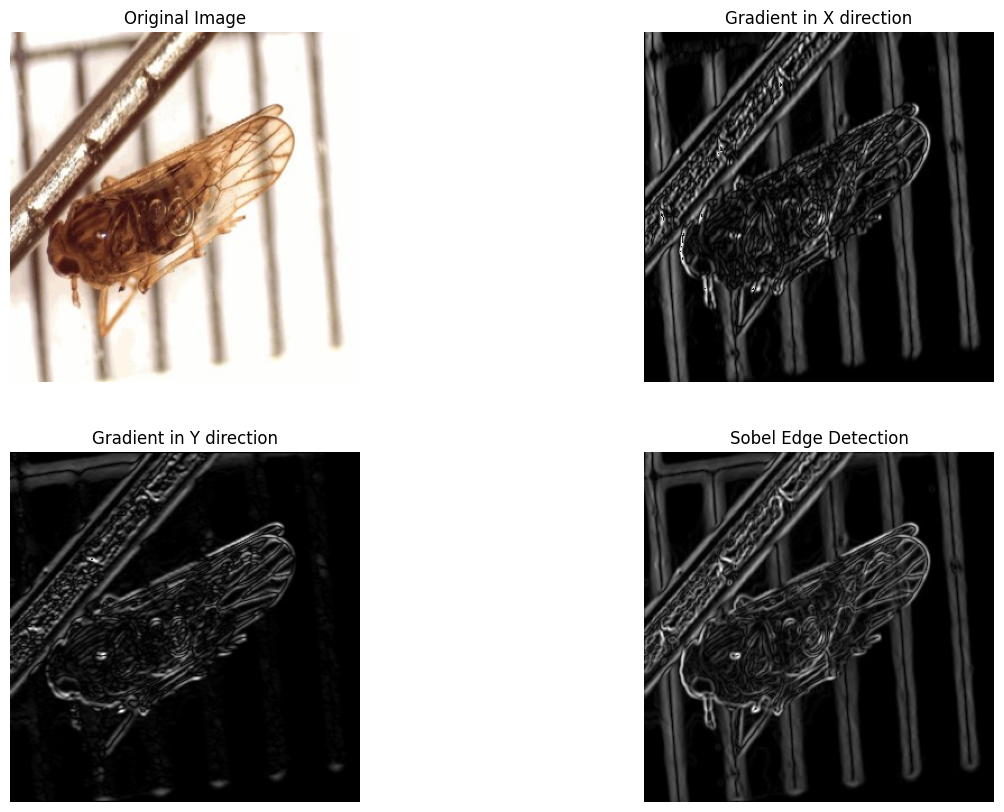

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/drive/MyDrive/Pest_V2/brown plant hopper/adult/04451.jpg'
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian smoothing (optional)
blurred_image = cv2.GaussianBlur(gray_image, (3,3),0)

# Sobel operators
Gx = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)

# Normalize to range 0-255
Gx = np.uint8(255 * np.abs(Gx) / np.max(Gx))
Gy = np.uint8(255 * np.abs(Gy)/ np.max(Gy))
G = np.uint8(255 * G / np.max(G))

# Display the results
plt.figure(figsize=(15,10))

# Original image
plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Gradient in X direction
plt.subplot(2,2,2)
plt.imshow(Gx, cmap='gray')
plt.title('Gradient in X direction')
plt.axis('off')

# Gradient in Y direction
plt.subplot(2,2,3)
plt.imshow(Gy, cmap='gray')
plt.title('Gradient in Y direction')
plt.axis('off')

# Edge-detected image
plt.subplot(2,2,4)
plt.imshow(G, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

plt.show()

# Canny Edge Detection

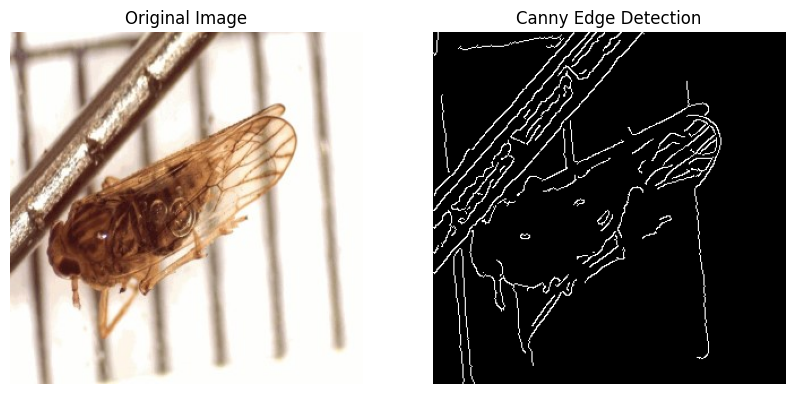

In [2]:
# Load the image
image = cv2.imread(image_path, cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image,(5,5), 1.4)

# Apply Canny edge detector
edges = cv2.Canny(blurred_image, 100, 200)

# Display the result
plt.figure(figsize=(10,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Edge-detected image

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()

# Laplacian Edge Detection

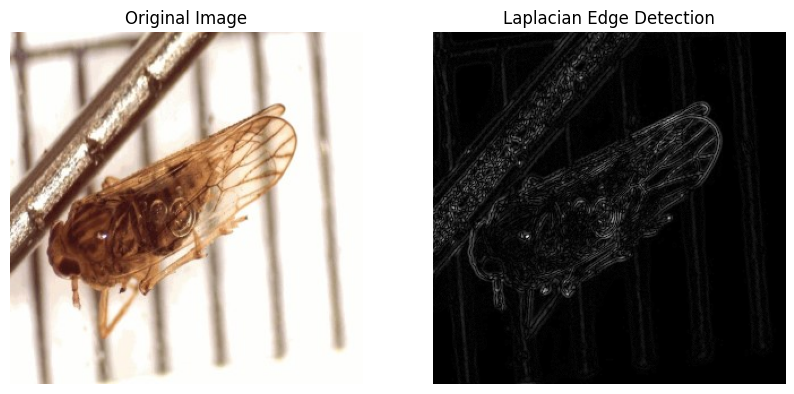

In [3]:
# Load the image
image = cv2.imread(image_path, cv2.IMREAD_COLOR)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (3,3), 0)

# Apply the Laplacian
laplacian = cv2.Laplacian(blurred_image, cv2.CV_64F)

# Convert the result to 8-bit (0-255) range
laplacian_abs = cv2.convertScaleAbs(laplacian)

# Display the result
plt.figure(figsize=(10,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Laplacian edge-detected
plt.subplot(1,2,2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

plt.show()

# Prewitt Edge Detection

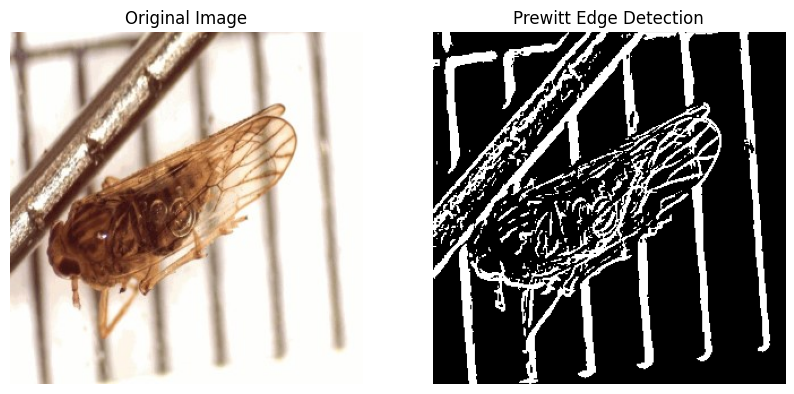

In [6]:
def prewitt_edge_detection(image):

  # Convert the image to grayscale
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Apply horizontal Prewitt kernel
  kernel_x = np.array([[-1,0,1],
                       [-1,0,1],
                       [-1,0,1]])

  horizontal_edges = cv2.filter2D(gray_image, -1, kernel_x)

  # Apply vertical Prewitt kernel
  kernel_y = np.array([[-1,-1,-1],
                       [0,0,0],
                       [1,1,1]])

  vertical_edges = cv2.filter2D(gray_image, -1, kernel_y)

  # Ensure both arrays have the same data type
  horizontal_edges = np.float32(horizontal_edges)
  vertical_edges = np.float32(vertical_edges)

  # Compute gradient magnitude
  gradient_magnitude = cv2.magnitude(horizontal_edges, vertical_edges)

  # Optional Apply thresholding to highlight edges
  threshold = 50
  _, edges = cv2.threshold(gradient_magnitude, threshold, 255, cv2.THRESH_BINARY)

  return edges

# Input image
image = cv2.imread(image_path)

# Apply Prewitt edge detection
edges = prewitt_edge_detection(image)

# Plotting both images using subplots
plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Detected edges
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')

plt.show()